# Cluster similarity with MetaNeighbor

In [1]:
%load_ext autoreload

In [2]:

import pickle
from os.path import join

import anndata
import pymn
from IPython.display import display, Markdown

## Load data

In [3]:
CACHE_DIR = "/vol/data/dataset-similarity/cache"
SAVE_DIR = "/vol/data/dataset-similarity/models/pyMN"
FIG_DIR = "/vol/data/dataset-similarity/figures/pyMN"

QUERY_DATASET = "f6c50495-3361-40ed-a819-fb9644396ed9_updated"
REF_DATASET = "ced320a1-29f3-47c1-a735-513c7084d508_CAP"

N_TOP_GENES = 3000

In [4]:
cache_file = join(
    CACHE_DIR, 
    "+".join([QUERY_DATASET, REF_DATASET, f"{N_TOP_GENES}HVGs"]) + ".pickle"
)
with open(cache_file, "rb") as f:
    adata_query, adata_ref = pickle.load(f)

In [5]:
adata_query

AnnData object with n_obs × n_vars = 263159 × 3000
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'AuthorCellType', 'cell_type_author', 'sample_id'
    uns: 'de_res_ova', 'de_res_ava'

In [6]:
adata_ref

AnnData object with n_obs × n_vars = 1265624 × 3000
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'sample_uuid', 'author_cell_type', 'cell_type_author', 'sample_id'
    var: 'feature_id'
    uns: 'de_res_ova', 'de_res_ava'
    obsm: 'X_scTab', 'X_scimilarity'

In [7]:
adata = anndata.concat(
    [adata_query, adata_ref], 
    label="dataset", 
    keys=["query", "ref"]
)
adata

AnnData object with n_obs × n_vars = 1528783 × 3000
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'cell_type_author', 'sample_id', 'dataset'

In [8]:
# MetaNeighbor only works on dense data
adata.X = adata.X.toarray()
# MetaNeighbor does not work with categorical columns
adata.obs["dataset"] = adata.obs["dataset"].astype(str)
adata.obs["cell_type_author"] = adata.obs["cell_type_author"].astype(str)

In [9]:
pymn.variableGenes(adata, study_col="dataset")

## Run MetaNeighbor

In [10]:
pymn.MetaNeighborUS(
    adata,
    study_col="dataset",
    ct_col="cell_type_author",
    fast_version=True
)

In [11]:
mapping = adata.uns["MetaNeighborUS"]
mapping = mapping.loc[
    mapping.index.str.startswith("query"),
    mapping.columns.str.startswith("ref")
]
mapping.index = mapping.index.str.removeprefix("query|")
mapping.columns = mapping.columns.str.removeprefix("ref|")

## Visualize cluster similarities

In [12]:
%autoreload
from pairot.plotting import plot_cluster_mapping

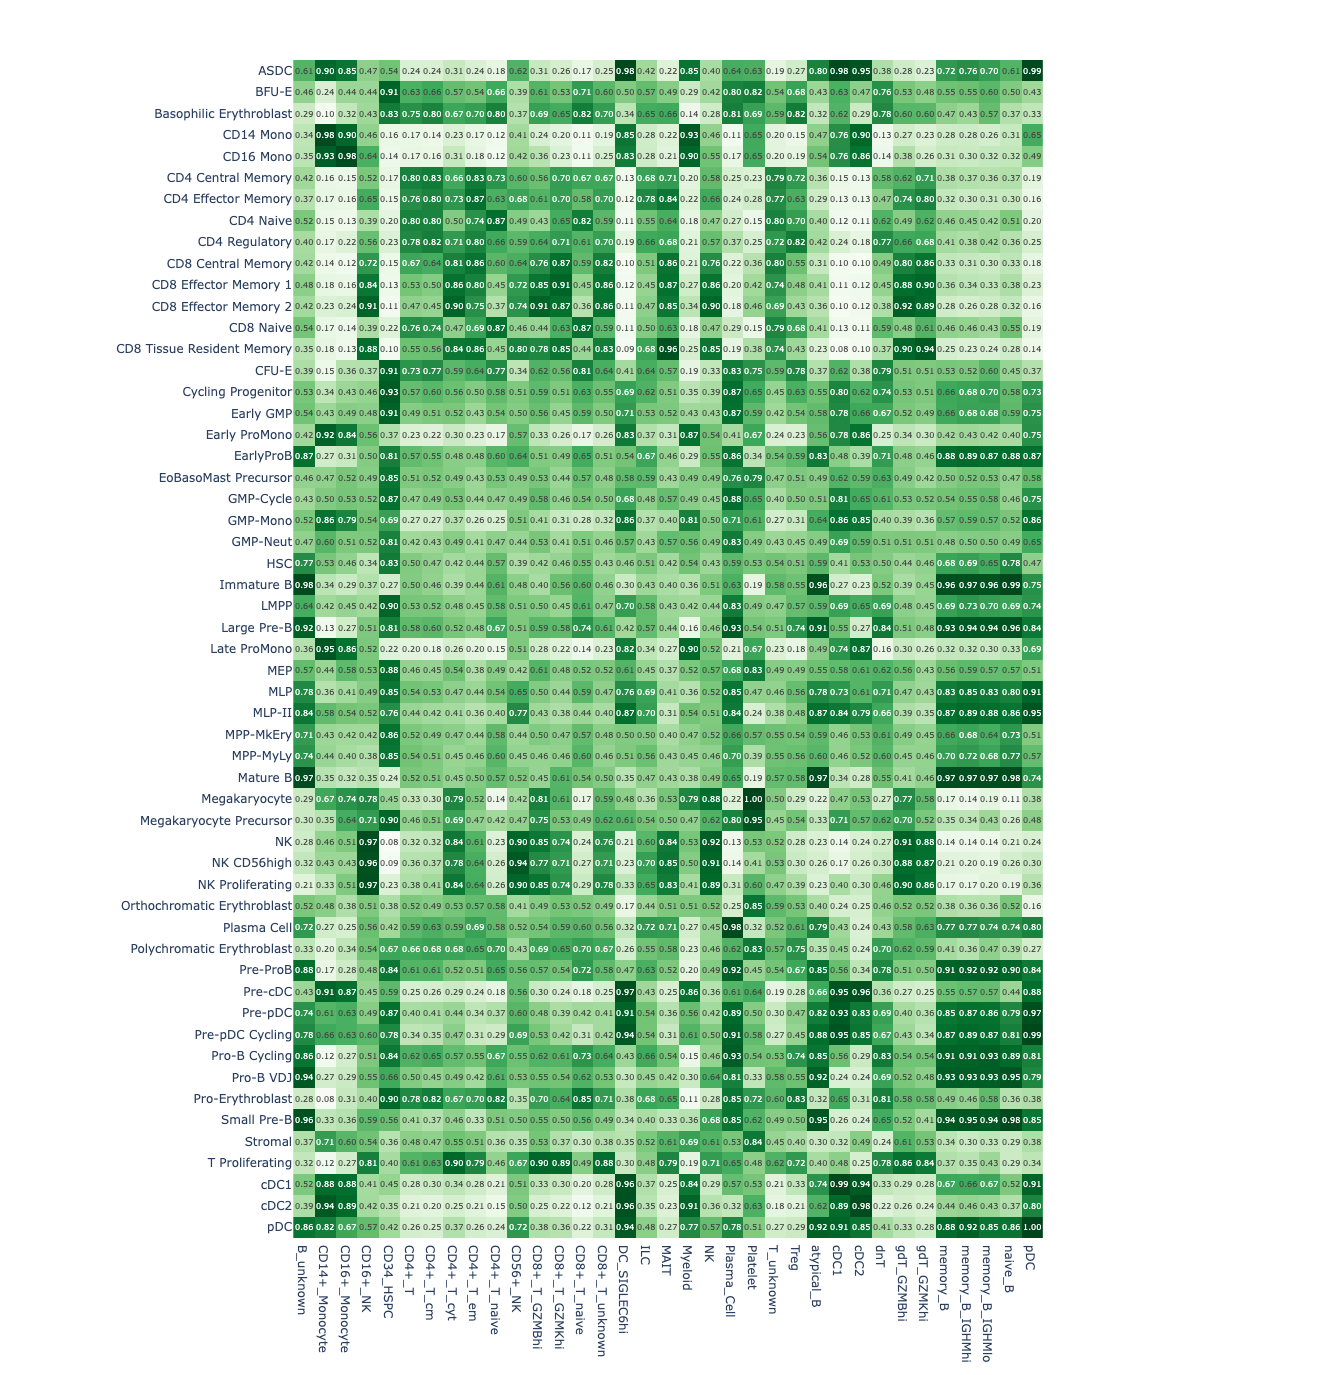

In [18]:
fig = plot_cluster_mapping(mapping, show=False, sort_by_score=False)
fig.update_layout(coloraxis_showscale=False)

In [14]:
mapping.to_parquet("pyMN_mapping.parquet")

In [15]:
fig.write_image("plots/pyMN-immune-example.svg")

In [16]:
top_hits_mn = pymn.topHits(adata, save_uns=False)

ind = top_hits_mn["Study_ID|Celltype_1"].str.startswith("ref|")
top_hits_mn.loc[ind, "Study_ID|Celltype_1"], top_hits_mn.loc[ind, "Study_ID|Celltype_2"] = (
    top_hits_mn.loc[ind, "Study_ID|Celltype_2"], top_hits_mn.loc[ind, "Study_ID|Celltype_1"]
)
top_hits_mn["Study_ID|Celltype_1"] = top_hits_mn["Study_ID|Celltype_1"].str.removeprefix("query|")
top_hits_mn["Study_ID|Celltype_2"] = top_hits_mn["Study_ID|Celltype_2"].str.removeprefix("ref|")


top_hits_mn = (
    top_hits_mn[["Study_ID|Celltype_1", "Study_ID|Celltype_2"]]
    .groupby("Study_ID|Celltype_1")
    ["Study_ID|Celltype_2"].unique().map(list)
    .to_dict()
)


summaries = []
for i, k in enumerate(mapping.index):
    v = top_hits_mn.get(k, [])
    summaries.append(f"*{i+1}*: **{k}**: {v} <br>")

display(Markdown("".join(summaries)))    

*1*: **ASDC**: ['pDC', 'DC_SIGLEC6hi'] <br>*2*: **BFU-E**: [] <br>*3*: **Basophilic Erythroblast**: [] <br>*4*: **CD14 Mono**: ['CD14+_Monocyte'] <br>*5*: **CD16 Mono**: ['CD16+_Monocyte'] <br>*6*: **CD4 Central Memory**: [] <br>*7*: **CD4 Effector Memory**: [] <br>*8*: **CD4 Naive**: [] <br>*9*: **CD4 Regulatory**: [] <br>*10*: **CD8 Central Memory**: [] <br>*11*: **CD8 Effector Memory 1**: [] <br>*12*: **CD8 Effector Memory 2**: [] <br>*13*: **CD8 Naive**: [] <br>*14*: **CD8 Tissue Resident Memory**: ['MAIT'] <br>*15*: **CFU-E**: [] <br>*16*: **Cycling Progenitor**: [] <br>*17*: **Early GMP**: [] <br>*18*: **Early ProMono**: [] <br>*19*: **EarlyProB**: [] <br>*20*: **EoBasoMast Precursor**: [] <br>*21*: **GMP-Cycle**: [] <br>*22*: **GMP-Mono**: [] <br>*23*: **GMP-Neut**: [] <br>*24*: **HSC**: [] <br>*25*: **Immature B**: ['naive_B', 'B_unknown'] <br>*26*: **LMPP**: [] <br>*27*: **Large Pre-B**: ['naive_B'] <br>*28*: **Late ProMono**: [] <br>*29*: **MEP**: [] <br>*30*: **MLP**: [] <br>*31*: **MLP-II**: ['pDC'] <br>*32*: **MPP-MkEry**: [] <br>*33*: **MPP-MyLy**: [] <br>*34*: **Mature B**: ['naive_B', 'memory_B', 'memory_B_IGHMhi', 'atypical_B', 'memory_B_IGHMlo'] <br>*35*: **Megakaryocyte**: ['Platelet'] <br>*36*: **Megakaryocyte Precursor**: ['Platelet'] <br>*37*: **NK**: ['CD16+_NK'] <br>*38*: **NK CD56high**: ['CD16+_NK'] <br>*39*: **NK Proliferating**: ['CD16+_NK'] <br>*40*: **Orthochromatic Erythroblast**: [] <br>*41*: **Plasma Cell**: ['Plasma_Cell'] <br>*42*: **Polychromatic Erythroblast**: [] <br>*43*: **Pre-ProB**: [] <br>*44*: **Pre-cDC**: ['DC_SIGLEC6hi'] <br>*45*: **Pre-pDC**: ['pDC'] <br>*46*: **Pre-pDC Cycling**: ['pDC'] <br>*47*: **Pro-B Cycling**: [] <br>*48*: **Pro-B VDJ**: ['naive_B'] <br>*49*: **Pro-Erythroblast**: [] <br>*50*: **Small Pre-B**: ['naive_B'] <br>*51*: **Stromal**: [] <br>*52*: **T Proliferating**: [] <br>*53*: **cDC1**: ['cDC1'] <br>*54*: **cDC2**: ['cDC2'] <br>*55*: **pDC**: ['pDC'] <br>

In [17]:
top_hits_mn = pymn.topHits(adata, save_uns=False, threshold=0.9)

ind = top_hits_mn["Study_ID|Celltype_1"].str.startswith("ref|")
top_hits_mn.loc[ind, "Study_ID|Celltype_1"], top_hits_mn.loc[ind, "Study_ID|Celltype_2"] = (
    top_hits_mn.loc[ind, "Study_ID|Celltype_2"], top_hits_mn.loc[ind, "Study_ID|Celltype_1"]
)
top_hits_mn["Study_ID|Celltype_1"] = top_hits_mn["Study_ID|Celltype_1"].str.removeprefix("query|")
top_hits_mn["Study_ID|Celltype_2"] = top_hits_mn["Study_ID|Celltype_2"].str.removeprefix("ref|")


top_hits_mn = (
    top_hits_mn[["Study_ID|Celltype_1", "Study_ID|Celltype_2"]]
    .groupby("Study_ID|Celltype_1")
    ["Study_ID|Celltype_2"].unique().map(list)
    .to_dict()
)


summaries = []
for i, k in enumerate(mapping.index):
    v = top_hits_mn.get(k, [])
    summaries.append(f"*{i+1}*: **{k}**: {v} <br>")

display(Markdown("".join(summaries))) 

*1*: **ASDC**: ['pDC', 'DC_SIGLEC6hi'] <br>*2*: **BFU-E**: ['CD34_HSPC'] <br>*3*: **Basophilic Erythroblast**: [] <br>*4*: **CD14 Mono**: ['CD14+_Monocyte', 'Myeloid'] <br>*5*: **CD16 Mono**: ['CD16+_Monocyte'] <br>*6*: **CD4 Central Memory**: [] <br>*7*: **CD4 Effector Memory**: [] <br>*8*: **CD4 Naive**: [] <br>*9*: **CD4 Regulatory**: [] <br>*10*: **CD8 Central Memory**: [] <br>*11*: **CD8 Effector Memory 1**: ['CD8+_T_GZMKhi'] <br>*12*: **CD8 Effector Memory 2**: ['gdT_GZMBhi', 'CD8+_T_GZMBhi', 'CD4+_T_cyt'] <br>*13*: **CD8 Naive**: [] <br>*14*: **CD8 Tissue Resident Memory**: ['MAIT', 'gdT_GZMKhi'] <br>*15*: **CFU-E**: ['CD34_HSPC'] <br>*16*: **Cycling Progenitor**: ['CD34_HSPC'] <br>*17*: **Early GMP**: ['CD34_HSPC'] <br>*18*: **Early ProMono**: ['CD14+_Monocyte'] <br>*19*: **EarlyProB**: [] <br>*20*: **EoBasoMast Precursor**: [] <br>*21*: **GMP-Cycle**: [] <br>*22*: **GMP-Mono**: [] <br>*23*: **GMP-Neut**: [] <br>*24*: **HSC**: [] <br>*25*: **Immature B**: ['naive_B', 'B_unknown'] <br>*26*: **LMPP**: ['CD34_HSPC'] <br>*27*: **Large Pre-B**: ['naive_B'] <br>*28*: **Late ProMono**: ['CD14+_Monocyte'] <br>*29*: **MEP**: [] <br>*30*: **MLP**: ['pDC'] <br>*31*: **MLP-II**: ['pDC'] <br>*32*: **MPP-MkEry**: [] <br>*33*: **MPP-MyLy**: [] <br>*34*: **Mature B**: ['naive_B', 'memory_B', 'memory_B_IGHMhi', 'atypical_B', 'memory_B_IGHMlo'] <br>*35*: **Megakaryocyte**: ['Platelet'] <br>*36*: **Megakaryocyte Precursor**: ['Platelet'] <br>*37*: **NK**: ['CD16+_NK', 'NK'] <br>*38*: **NK CD56high**: ['CD16+_NK', 'CD56+_NK'] <br>*39*: **NK Proliferating**: ['CD16+_NK'] <br>*40*: **Orthochromatic Erythroblast**: [] <br>*41*: **Plasma Cell**: ['Plasma_Cell'] <br>*42*: **Polychromatic Erythroblast**: [] <br>*43*: **Pre-ProB**: ['memory_B_IGHMlo'] <br>*44*: **Pre-cDC**: ['DC_SIGLEC6hi'] <br>*45*: **Pre-pDC**: ['pDC'] <br>*46*: **Pre-pDC Cycling**: ['pDC'] <br>*47*: **Pro-B Cycling**: ['Plasma_Cell'] <br>*48*: **Pro-B VDJ**: ['naive_B'] <br>*49*: **Pro-Erythroblast**: [] <br>*50*: **Small Pre-B**: ['naive_B'] <br>*51*: **Stromal**: [] <br>*52*: **T Proliferating**: ['CD8+_T_GZMBhi'] <br>*53*: **cDC1**: ['cDC1'] <br>*54*: **cDC2**: ['cDC2'] <br>*55*: **pDC**: ['pDC'] <br>